In [1]:
import requests
import geopandas as gpd
import io
import plotly.express as px
import json
import folium
import matplotlib.pyplot as plt

In [2]:
# Import données
gdf = gpd.read_file("data/Yearly_exposure_to_active_substance_in_use_air_and_water.gpkg")
gdf.shape

(5484720, 11)

In [3]:
# Données
print(gdf.head())


   id    year  mean_concentration_air  mean_concentration_scale_air  \
0   1  2013.0                2.636647                      0.045801   
1   2  2013.0                2.657499                      0.046163   
2   3  2013.0                2.651188                      0.046054   
3   4  2013.0                2.644819                      0.045943   
4   5  2013.0                2.638395                      0.045832   

        area  mean_tii  mean_tii_scale  mean_concentration_water  \
0  1000000.0  0.907858        0.040737                       0.0   
1  1000000.0  0.970098        0.043530                       0.0   
2  1000000.0  1.133791        0.050875                       0.0   
3  1000000.0  1.133791        0.050875                       0.0   
4  1000000.0  0.602152        0.027020                       0.0   

   mean_concentration_scale_water  all_pesticide_exposure  \
0                             0.0                0.086538   
1                             0.0         

In [4]:
# Nom des colonnes
print(gdf.columns.tolist())

['id', 'year', 'mean_concentration_air', 'mean_concentration_scale_air', 'area', 'mean_tii', 'mean_tii_scale', 'mean_concentration_water', 'mean_concentration_scale_water', 'all_pesticide_exposure', 'geometry']


In [5]:
# Description
gdf.describe()

,id,year,mean_concentration_air,mean_concentration_scale_air,area,mean_tii,mean_tii_scale,mean_concentration_water,mean_concentration_scale_water,all_pesticide_exposure
count,5.484720e+06,5.484720e+06,5.484720e+06,5.484720e+06,5.484720e+06,5.484720e+06,5.484720e+06,5.483960e+06,5.483960e+06,5.483960e+06
mean,2.742365e+05,2.017500e+03,3.507200e+00,6.092366e-02,1.000000e+06,1.105760e+00,4.961734e-02,2.740794e-01,3.055530e-02,1.410943e-01
std,1.583302e+05,2.872282e+00,4.048474e+00,7.032614e-02,4.021472e-09,1.429867e+00,6.416059e-02,6.284021e-01,7.005638e-02,1.523161e-01
min,1.000000e+00,2.013000e+03,0.000000e+00,0.000000e+00,1.000000e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.371188e+05,2.015000e+03,1.277205e+00,2.218637e-02,1.000000e+06,1.059719e-01,4.755142e-03,0.000000e+00,0.000000e+00,3.789381e-02
50%,2.742365e+05,2.017500e+03,2.148646e+00,3.732419e-02,1.000000e+06,5.974782e-01,2.680987e-02,1.804628e-03,2.011860e-04,8.765769e-02
75%,4.113542e+05,2.020000e+03,4.160210e+00,7.226711e-02,1.000000e+06,1.557193e+00,6.987392e-02,2.600000e-01,2.898568e-02,1.880732e-01
max,5.484720e+05,2.022000e+03,2.878356e+01,5.000000e-01,1.000000e+06,1.114288e+01,5.000000e-01,4.484974e+00,5.000000e-01,1.500000e+00


In [6]:
# Compréheension des données
print(gdf.dtypes)
print("Systeme de projection:", gdf.crs)               # système de projection

id                                   int32
year                               float64
mean_concentration_air             float64
mean_concentration_scale_air       float64
area                               float64
mean_tii                           float64
mean_tii_scale                     float64
mean_concentration_water           float64
mean_concentration_scale_water     float64
all_pesticide_exposure             float64
geometry                          geometry
dtype: object
Systeme de projection: EPSG:2154


In [7]:
# Selection des colonnes
col = "mean_tii"  
col_to_show = ['mean_concentration_air', 'mean_tii', 'mean_concentration_water', 'all_pesticide_exposure']

In [8]:
# Forcer l'id comme index et choisir l'année la plus récente
gdf = gdf[gdf["year"]==gdf["year"].max()].reset_index(drop=True)
gdf["id"] = gdf.index.astype(str) 

In [9]:
gdf.describe()

,year,mean_concentration_air,mean_concentration_scale_air,area,mean_tii,mean_tii_scale,mean_concentration_water,mean_concentration_scale_water,all_pesticide_exposure
count,548472.0,548472.000000,548472.000000,5.484720e+05,548472.000000,548472.000000,548396.000000,548396.000000,548396.000000
mean,2022.0,5.361965,0.093143,1.000000e+06,1.233192,0.055335,0.227484,0.025361,0.173848
std,0.0,4.524347,0.078593,4.021475e-09,1.515436,0.068000,0.536373,0.059797,0.163517
min,2022.0,1.355373,0.023544,1.000000e+06,0.000000,0.000000,0.000000,0.000000,0.024339
25%,2022.0,2.362719,0.041043,1.000000e+06,0.120284,0.005397,0.000000,0.000000,0.053189
50%,2022.0,3.581908,0.062221,1.000000e+06,0.690871,0.031001,0.006707,0.000748,0.116052
75%,2022.0,6.479164,0.112550,1.000000e+06,1.770432,0.079442,0.215567,0.024032,0.235247
max,2022.0,28.783564,0.500000,1.000000e+06,11.142879,0.500000,4.484974,0.500000,1.500000


In [10]:
# 1. Reprojection obligatoire en WGS84
gdf_wgs84 = gdf.to_crs(epsg=4326)

# Test avec Plotly

In [9]:
# 2. S'assurer que id est en string (requis par Plotly)
gdf_wgs84["id"] = gdf_wgs84["id"].astype(str)

In [10]:
# 3. Construire le GeoJSON
geojson = json.loads(gdf_wgs84.to_json())

In [11]:
geojson["features"]

[{'id': '0',
  'type': 'Feature',
  'properties': {'id': '0',
   'mean_concentration': 7.175837887105083,
   'mean_concentration_scale': 0.1737696161741338,
   'area': 1000000.0,
   'mean_itt': 1.5754586578258405,
   'mean_itt_scale': 0.07792644511421705,
   'mean_concentration_water': 0.0,
   'mean_concentration_scale_water': 0.0,
   'all_pesticide_exposure': 0.25169606128835087},
  'geometry': {'type': 'Polygon',
   'coordinates': [[[2.5333049329879263, 51.088955377385325],
     [2.547544412178835, 51.08900757201262],
     [2.5476259907786316, 51.080039723222974],
     [2.5333890788750772, 51.079987537245444],
     [2.5333049329879263, 51.088955377385325]]]}},
 {'id': '1',
  'type': 'Feature',
  'properties': {'id': '1',
   'mean_concentration': 7.194964409910135,
   'mean_concentration_scale': 0.17423278278671187,
   'area': 1000000.0,
   'mean_itt': 1.6834681715457596,
   'mean_itt_scale': 0.0832688877107901,
   'mean_concentration_water': 0.0,
   'mean_concentration_scale_water': 

In [12]:
print(json.dumps(geojson["features"][0], indent=2))

{
  "id": "0",
  "type": "Feature",
  "properties": {
    "id": "0",
    "mean_concentration": 7.175837887105083,
    "mean_concentration_scale": 0.1737696161741338,
    "area": 1000000.0,
    "mean_itt": 1.5754586578258405,
    "mean_itt_scale": 0.07792644511421705,
    "mean_concentration_water": 0.0,
    "mean_concentration_scale_water": 0.0,
    "all_pesticide_exposure": 0.25169606128835087
  },
  "geometry": {
    "type": "Polygon",
    "coordinates": [
      [
        [
          2.5333049329879263,
          51.088955377385325
        ],
        [
          2.547544412178835,
          51.08900757201262
        ],
        [
          2.5476259907786316,
          51.080039723222974
        ],
        [
          2.5333890788750772,
          51.079987537245444
        ],
        [
          2.5333049329879263,
          51.088955377385325
        ]
      ]
    ]
  }
}


In [ ]:
# Carte
fig = px.choropleth_map(
    gdf_wgs84,
    geojson=geojson,
    locations="id",
    featureidkey="properties.id",
    color=col,
    color_continuous_scale="RdYlGn_r",
    #map_style="carto-positron",
    zoom=5,
    center={"lat": 46.5, "lon": 2.5},
    #opacity=0.6,
    title=f"Exposition : {col}",
    hover_data=col_to_show
)
fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
fig.show()

# Test avec Folium

In [11]:
gdf_wgs84["id"].dtype

<StringDtype(storage='python', na_value=nan)>

In [12]:
# Centre de la carte
centroid = gdf_wgs84.geometry.union_all().centroid
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=6, tiles="CartoDB Positron")

In [13]:
# Details
print(gdf_wgs84.shape)
gdf_wgs84.head()

(548472, 11)


,id,year,mean_concentration_air,mean_concentration_scale_air,area,mean_tii,mean_tii_scale,mean_concentration_water,mean_concentration_scale_water,all_pesticide_exposure,geometry
0,0,2022.0,8.740644,0.151834,1000000.0,1.612293,0.072346,0.0,0.0,0.224180,"POLYGON ((2.5333 51.08896, 2.54754 51.08901, 2..."
1,1,2022.0,8.740938,0.151839,1000000.0,1.722827,0.077306,0.0,0.0,0.229145,"POLYGON ((2.50492 51.07988, 2.51915 51.07993, ..."
2,2,2022.0,8.741790,0.151854,1000000.0,2.013536,0.090351,0.0,0.0,0.242205,"POLYGON ((2.51915 51.07993, 2.53339 51.07999, ..."
3,3,2022.0,8.742633,0.151868,1000000.0,2.013536,0.090351,0.0,0.0,0.242219,"POLYGON ((2.53339 51.07999, 2.54763 51.08004, ..."
4,4,2022.0,8.743465,0.151883,1000000.0,1.069381,0.047985,0.0,0.0,0.199868,"POLYGON ((2.54763 51.08004, 2.56186 51.08009, ..."


In [15]:
# Choroplèthe
folium.Choropleth(
    geo_data=gdf_wgs84.__geo_interface__,
    data=gdf_wgs84,
    columns=["id", col], 
    key_on="feature.id",
    fill_color="RdYlGn_r",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name=col,
    nan_fill_color="white"
).add_to(m)

In [ ]:
from IPython.display import display
display(m)

In [44]:
# Tooltip au survol
folium.GeoJson(
    gdf_wgs84,
    tooltip=folium.GeoJsonTooltip(fields=col_to_show)
).add_to(m)

In [16]:
# Export de la carte
m.save("carte_exposition_2022.html")
print("Carte sauvegardée → ouvrir carte_exposition.html dans le navigateur")


Carte sauvegardée → ouvrir carte_exposition.html dans le navigateur


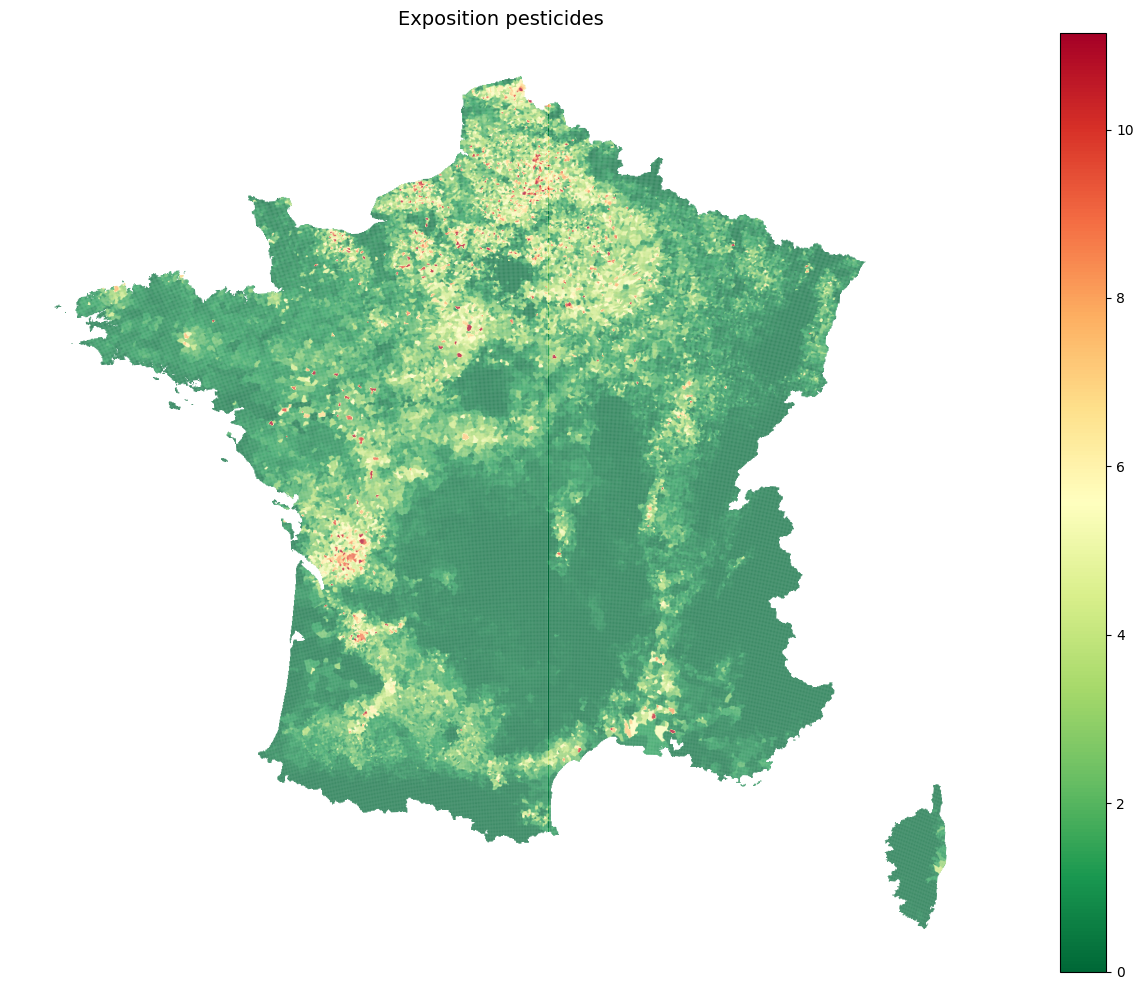

In [14]:
# Carte statique avec Matplotlib
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
gdf_wgs84.plot(
    column=col,
    cmap="RdYlGn_r",
    legend=True,
    ax=ax,
    edgecolor=None,
    linewidth=0.1)
ax.set_title("Exposition pesticides", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("carte.png", dpi=300, bbox_inches="tight")
plt.show()